# Import Libraries

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)


In [7]:
import shap

In [8]:
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


# Load Dataset

In [9]:
df = pd.read_csv("dataset/heart_disease_uci.csv")

In [10]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [11]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [12]:
# Remove ID column
df.drop("id", axis=1, inplace=True)

In [13]:
# Convert target to binary classification
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

# Handle Missing values

In [14]:
from sklearn.impute import SimpleImputer

# Numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("num")

# Categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Median imputation for numerical
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Most frequent for categorical
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Verify
print(df.isnull().sum())

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [15]:
df.drop_duplicates()

print(df.shape)

(920, 15)


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [17]:
X = df.drop("num", axis=1)
y = df["num"]

print(X.shape)
print(y.shape)

(920, 14)
(920,)


# Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train the Random Forest Model

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8261


# CLASSIFICATION REPORT

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        82
           1       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



# CONFUSION MATRIX

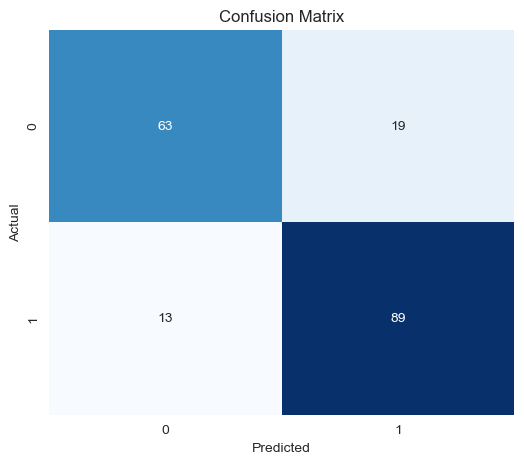

In [28]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [30]:
plt.savefig(
    "assets/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# ROC Curve & AUC

# (i) ROC Curve

In [35]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# Calculate AUC score

In [36]:
auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"AUC Score : {auc_score:.4f}")

AUC Score : 0.9295


# Plot ROC Curve

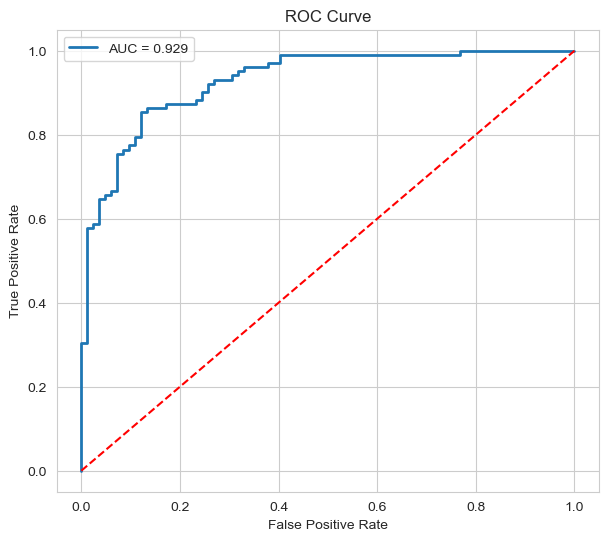

In [33]:
plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
plt.savefig(
    "assets/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Creating Summary Plot

In [37]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

<Figure size 640x480 with 0 Axes>

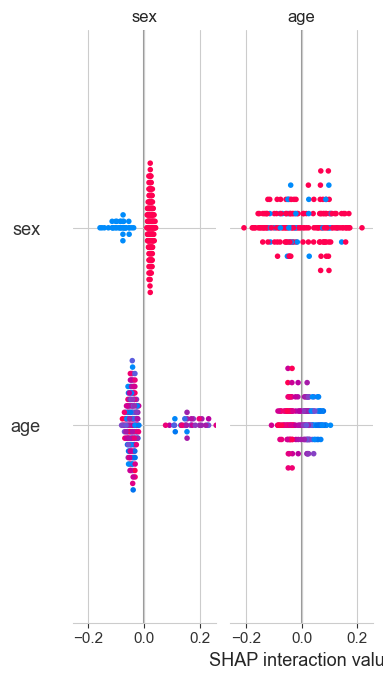

In [39]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=df.drop("num",axis=1).columns,
    show=False
)

plt.savefig(
    "assets/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Force Plot

In [41]:
import shap

In [54]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [55]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[:, :, 1][0],
    X_test.iloc[0],
    feature_names=X_test.columns
)